In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


file_path = 'indiancrop_dataset.xlsx'


df = pd.read_excel(file_path)

C:\Users\Home\AppData\Local\Temp\ipykernel_11880\26644617.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df.head()

,N_SOIL,P_SOIL,K_SOIL,TEMPERATURE,HUMIDITY,ph,RAINFALL,STATE,CROP_PRICE,CROP,DESTINATION,DISTANCE
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Andaman and Nicobar,7000,Rice,Andhra Pradesh,1200
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Andaman and Nicobar,5000,Rice,Andhra Pradesh,1200
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Andaman and Nicobar,7000,Rice,Tamil Nadu,1200
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Andaman and Nicobar,7000,Rice,West Bengal,1300
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Andaman and Nicobar,120000,Rice,Andhra Pradesh,1200


In [3]:
df.tail()

,N_SOIL,P_SOIL,K_SOIL,TEMPERATURE,HUMIDITY,ph,RAINFALL,STATE,CROP_PRICE,CROP,DESTINATION,DISTANCE
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,West Bengal,1000,Coffee,Odisha,500
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,West Bengal,800,Coffee,Odisha,500
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,West Bengal,560,Coffee,Odisha,500
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,West Bengal,1500,Coffee,Odisha,500
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,West Bengal,1400,Coffee,Odisha,500


In [4]:
df.isnull().sum()

N_SOIL         0
P_SOIL         0
K_SOIL         0
TEMPERATURE    0
HUMIDITY       0
ph             0
RAINFALL       0
STATE          0
CROP_PRICE     0
CROP           0
DESTINATION    0
DISTANCE       0
dtype: int64

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


features = ['N_SOIL', 'P_SOIL', 'K_SOIL',
            'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']
target = 'CROP'


X = df[features]
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)


y_pred = clf.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


print(classification_report(y_test, y_pred))

Accuracy: 0.99
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        17
      Cotton       1.00      1.00      1.00        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      1.00      0.96        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       0.92      1.00      0.96        11
       Maize       1.00      1.00      1.00        21
       Mango       1.00      1.00      1.00        19
   MothBeans       1.00      0.96      0.98        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00      1.00      1.00        14
      Papaya

In [6]:

data_test = {
    'N_SOIL': [23, 27, 19],
    'P_SOIL': [14, 10, 12],
    'K_SOIL': [22, 21, 25],
    'TEMPERATURE': [28, 25, 20],
    'HUMIDITY': [58, 62, 48],
    'ph': [6.6, 6.8, 6.2],
    'RAINFALL': [53, 45, 100]
}

df_test = pd.DataFrame(data_test)


X_test_new_scaled = scaler.transform(df_test)


y_pred_new = clf.predict(X_test_new_scaled)


df_test['Predicted_CROP'] = y_pred_new
print("\nPredicted Crop for the New Test Data:\n", df_test[[
      'N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL', 'Predicted_CROP']])


Predicted Crop for the New Test Data:
    N_SOIL  P_SOIL  K_SOIL  TEMPERATURE  HUMIDITY   ph  RAINFALL Predicted_CROP
0      23      14      22           28        58  6.6        53      MothBeans
1      27      10      21           25        62  6.8        45      MothBeans
2      19      12      25           20        48  6.2       100          Mango


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report


features = ['N_SOIL', 'P_SOIL', 'K_SOIL',
            'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']
target = 'CROP'


X = df[features]
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


clf = GaussianNB()
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


print(classification_report(y_test, y_pred))

Accuracy: 1.00
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       1.00      1.00      1.00        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       1.00      1.00      1.00        17
      Cotton       1.00      1.00      1.00        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      1.00      0.96        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       1.00      1.00      1.00        11
       Maize       1.00      1.00      1.00        21
       Mango       1.00      1.00      1.00        19
   MothBeans       1.00      1.00      1.00        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00      1.00      1.00        14
      Papaya

In [8]:

data_test = {
    'N_SOIL': [23, 27, 19],
    'P_SOIL': [14, 10, 12],
    'K_SOIL': [22, 21, 25],
    'TEMPERATURE': [50, 25, 20],
    'HUMIDITY': [8, 62, 48],
    'ph': [6.6, 6.8, 6.2],
    'RAINFALL': [81, 100, 40]
}

df_test = pd.DataFrame(data_test)


y_pred_new = clf.predict(df_test)


df_test['Predicted_CROP'] = y_pred_new
print("\nPredicted Crop for the New Test Data:\n", df_test[[
      'N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL', 'Predicted_CROP']])


Predicted Crop for the New Test Data:
    N_SOIL  P_SOIL  K_SOIL  TEMPERATURE  HUMIDITY   ph  RAINFALL Predicted_CROP
0      23      14      22           50         8  6.6        81     PigeonPeas
1      27      10      21           25        62  6.8       100          Mango
2      19      12      25           20        48  6.2        40      MothBeans


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


features = ['N_SOIL', 'P_SOIL', 'K_SOIL',
            'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']
target = 'CROP'


X = df[features]
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


print(classification_report(y_test, y_pred))

Accuracy: 0.99
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       0.95      1.00      0.98        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       0.96      1.00      0.98        27
      Coffee       1.00      1.00      1.00        17
      Cotton       1.00      1.00      1.00        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.92      0.96      0.94        23
 KidneyBeans       1.00      1.00      1.00        20
      Lentil       0.92      1.00      0.96        11
       Maize       1.00      0.95      0.98        21
       Mango       1.00      1.00      1.00        19
   MothBeans       1.00      0.92      0.96        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00      1.00      1.00        14
      Papaya

In [10]:
data_test = {
    'N_SOIL': [23, 27, 50],
    'P_SOIL': [14, 10, 12],
    'K_SOIL': [22, 21, 25],
    'TEMPERATURE': [28, 25, 81],
    'HUMIDITY': [58, 62, 48],
    'ph': [6.6, 6.8, 6.2],
    'RAINFALL': [100, 45, 89]
}

df_test = pd.DataFrame(data_test)


y_pred_new = clf.predict(df_test)


df_test['Predicted_CROP'] = y_pred_new
print("\nPredicted Crop for the New Test Data:\n", df_test[[
      'N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL', 'Predicted_CROP']])


Predicted Crop for the New Test Data:
    N_SOIL  P_SOIL  K_SOIL  TEMPERATURE  HUMIDITY   ph  RAINFALL Predicted_CROP
0      23      14      22           28        58  6.6       100          Mango
1      27      10      21           25        62  6.8        45      MothBeans
2      50      12      25           81        48  6.2        89          Mango


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


features = ['N_SOIL', 'P_SOIL', 'K_SOIL',
            'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']
target = 'CROP'


X = df[features]
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


k = 3
clf = KNeighborsClassifier(n_neighbors=k)
clf.fit(X_train_scaled, y_train)


y_pred = clf.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


print(classification_report(y_test, y_pred))

Accuracy: 0.97
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        23
      Banana       1.00      1.00      1.00        21
   Blackgram       1.00      0.95      0.97        20
    ChickPea       1.00      1.00      1.00        26
     Coconut       1.00      1.00      1.00        27
      Coffee       0.94      1.00      0.97        17
      Cotton       0.94      1.00      0.97        17
      Grapes       1.00      1.00      1.00        14
        Jute       0.85      0.96      0.90        23
 KidneyBeans       0.91      1.00      0.95        20
      Lentil       0.73      1.00      0.85        11
       Maize       1.00      0.95      0.98        21
       Mango       0.90      1.00      0.95        19
   MothBeans       1.00      0.88      0.93        24
    MungBean       1.00      1.00      1.00        19
   Muskmelon       1.00      1.00      1.00        17
      Orange       1.00      1.00      1.00        14
      Papaya

In [12]:

data_test = {
    'N_SOIL': [23, 27, 19],
    'P_SOIL': [14, 10, 12],
    'K_SOIL': [22, 21, 25],
    'TEMPERATURE': [28, 25, 20],
    'HUMIDITY': [58, 62, 48],
    'ph': [6.6, 6.8, 6.2],
    'RAINFALL': [53, 45, 40]
}

df_test = pd.DataFrame(data_test)


X_test_new_scaled = scaler.transform(df_test)


y_pred_new = clf.predict(X_test_new_scaled)


df_test['Predicted_CROP'] = y_pred_new
print("\nPredicted Crop for the New Test Data:\n", df_test[[
      'N_SOIL', 'P_SOIL', 'K_SOIL', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL', 'Predicted_CROP']])


Predicted Crop for the New Test Data:
    N_SOIL  P_SOIL  K_SOIL  TEMPERATURE  HUMIDITY   ph  RAINFALL Predicted_CROP
0      23      14      22           28        58  6.6        53          Mango
1      27      10      21           25        62  6.8        45      MothBeans
2      19      12      25           20        48  6.2        40      MothBeans


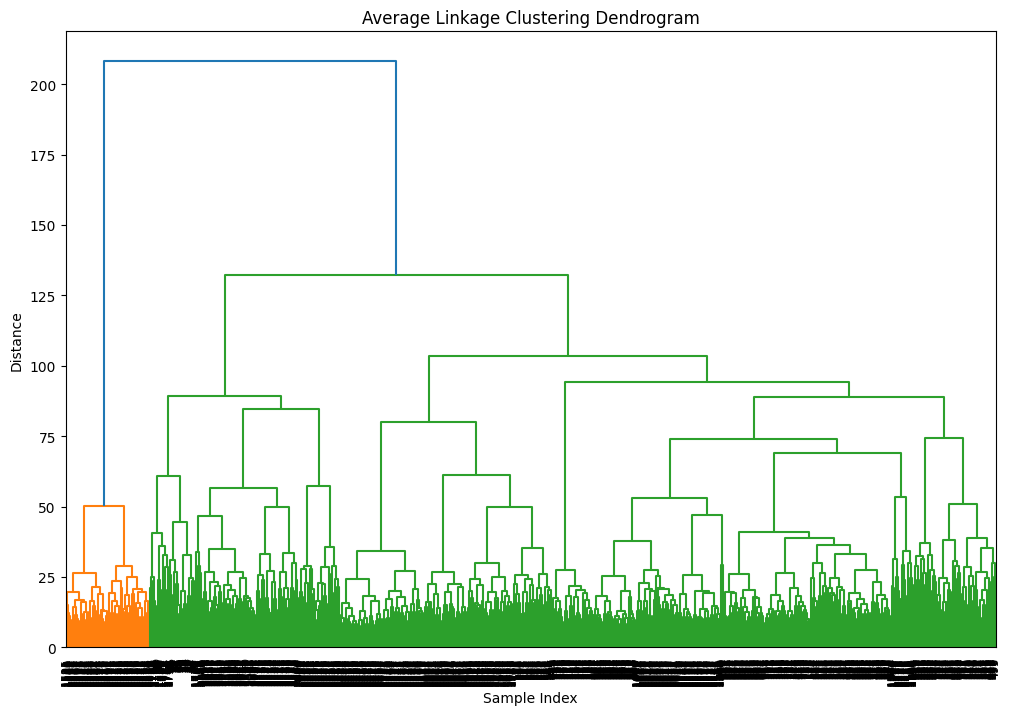

In [13]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt


features = ['N_SOIL', 'P_SOIL', 'K_SOIL',
            'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']


X = df[features]


linkage_matrix = linkage(X, method='average', metric='euclidean')


plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=df.index, leaf_rotation=90, leaf_font_size=8)
plt.title('Average Linkage Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [16]:
from sklearn.metrics import adjusted_rand_score, make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import AgglomerativeClustering

# Assuming y_train contains the true cluster labels

# Defining the corrected parameter grid
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    # Exclude 'ward' for non-Euclidean affinities
    'linkage': ['complete', 'average', 'single']
}

# Creating Agglomerative Clustering model
model = AgglomerativeClustering()

# Creating GridSearchCV
grid_search = GridSearchCV(
    model, param_grid, scoring='adjusted_rand_score', cv=5, n_jobs=-1)

# Fitting the grid search to the data
grid_search.fit(X_train)

# Getting the best parameters and the corresponding model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Fitting the best model to the data
best_model.fit(X_train)

# Getting the labels and ARI score
best_labels = best_model.labels_
best_ari_score = adjusted_rand_score(y_train, best_labels)

# Calculate accuracy score
accuracy = accuracy_score(y_train, best_labels)

print("Best Parameters: ", best_params)
print("Best Adjusted Rand Index (ARI): ", best_ari_score)
print("Accuracy Score: {:.2%}".format(accuracy))

Best Parameters:  {'linkage': 'complete', 'n_clusters': 2}
Best Adjusted Rand Index (ARI):  0.041941827786423316
Accuracy Score: 0.00%


C:\Users\Home\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [15]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


file_path = 'indiancrop_dataset.xlsx'


df = pd.read_excel(file_path)

In [16]:
import pandas as pd
import numpy as np

# Load your dataset
# Replace 'path/to/your/dataset.csv' with the actual path to your dataset file
file_path = 'indiancrop_dataset.xlsx'


df = pd.read_excel(file_path)

In [1]:
import pandas as pd
import numpy as np

# Load your dataset
# Replace 'path/to/your/dataset.csv' with the actual path to your dataset file
file_path = 'indiancrop_dataset.xlsx'


df = pd.read_excel(file_path)


# Assuming df is your original DataFrame

# Selecting only the desired columns
selected_columns = ['STATE', 'CROP_PRICE', 'CROP', 'DESTINATION', 'DISTANCE']
filtered_df = df[selected_columns]

# Display the resulting DataFrame
print(filtered_df)
# Specify the desired state and crop
desired_state = 'Gujarat'
desired_crop = 'Maize'

# Filter the DataFrame based on the specified state and crop
filtered_df = df.loc[(df['STATE'] == desired_state) & (
    df['CROP'] == desired_crop), selected_columns]

# Display the resulting DataFrame
print(filtered_df)

# Group by 'STATE' and 'DESTINATION', and calculate the average 'CROP_PRICE'
result_df = filtered_df.groupby(
    ['STATE', 'DESTINATION', "DISTANCE", "CROP"], as_index=False)['CROP_PRICE'].mean()

# Display the resulting DataFrame
print(result_df)

# Your provided data
data = result_df

# Convert data to a numpy array for easier manipulation
np_data = np.array([data['CROP_PRICE'], data['DISTANCE']]).T

# Parameters for ACO
n_ants = 5
n_iterations = 100
decay = 0.6
alpha = 1.0  # pheromone influence
beta = 2.0   # distance influence

# Initialize pheromone levels
pheromone = np.ones(len(np_data))

for i in range(n_iterations):
    ants = np.zeros((n_ants, len(np_data)), dtype=int)

    # Ants construct solutions
    for ant in range(n_ants):
        for j in range(len(np_data)):
            choices = np.delete(np.arange(len(np_data)), ants[ant, :j])
            probabilities = (pheromone[choices] ** alpha) * \
                ((1.0 / np_data[choices][:, 1]) ** beta)
            probabilities /= probabilities.sum()

            selected_index = np.random.choice(choices, p=probabilities)
            ants[ant, j] = selected_index

    # Update pheromone levels
    pheromone *= (1.0 - decay)
    for ant in range(n_ants):
        for j in range(len(np_data) - 1):
            pheromone[ants[ant, j]] += 1.0 / np_data[ants[ant, j], 0]

# Find the best solution
min_distance_index = np.argmin(np_data[:, 1])
best_solution = data['DESTINATION'][min_distance_index]

print("Best solution:", best_solution)

C:\Users\Home\AppData\Local\Temp\ipykernel_1816\316428106.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


                    STATE  CROP_PRICE    CROP     DESTINATION  DISTANCE
0     Andaman and Nicobar        7000    Rice  Andhra Pradesh      1200
1     Andaman and Nicobar        5000    Rice  Andhra Pradesh      1200
2     Andaman and Nicobar        7000    Rice      Tamil Nadu      1200
3     Andaman and Nicobar        7000    Rice     West Bengal      1300
4     Andaman and Nicobar      120000    Rice  Andhra Pradesh      1200
...                   ...         ...     ...             ...       ...
2195          West Bengal        1000  Coffee          Odisha       500
2196          West Bengal         800  Coffee          Odisha       500
2197          West Bengal         560  Coffee          Odisha       500
2198          West Bengal        1500  Coffee          Odisha       500
2199          West Bengal        1400  Coffee          Odisha       500

[2200 rows x 5 columns]
       STATE  CROP_PRICE   CROP  DESTINATION  DISTANCE
100  Gujarat        2600  Maize  Maharashtra       400
1

In [21]:
import pandas as pd

# Assuming df is your original DataFrame

# Selecting only the desired columns
selected_columns = ['STATE', 'CROP_PRICE', 'CROP', 'DESTINATION', 'DISTANCE']
filtered_df = df[selected_columns]

# Display the resulting DataFrame
print(filtered_df)

                    STATE  CROP_PRICE    CROP     DESTINATION  DISTANCE
0     Andaman and Nicobar        7000    Rice  Andhra Pradesh      1200
1     Andaman and Nicobar        5000    Rice  Andhra Pradesh      1200
2     Andaman and Nicobar        7000    Rice      Tamil Nadu      1200
3     Andaman and Nicobar        7000    Rice     West Bengal      1300
4     Andaman and Nicobar      120000    Rice  Andhra Pradesh      1200
...                   ...         ...     ...             ...       ...
2195          West Bengal        1000  Coffee          Odisha       500
2196          West Bengal         800  Coffee          Odisha       500
2197          West Bengal         560  Coffee          Odisha       500
2198          West Bengal        1500  Coffee          Odisha       500
2199          West Bengal        1400  Coffee          Odisha       500

[2200 rows x 5 columns]


In [27]:
# Specify the desired state and crop
desired_state = 'Gujarat'
desired_crop = 'Maize'

# Filter the DataFrame based on the specified state and crop
filtered_df = df.loc[(df['STATE'] == desired_state) & (
    df['CROP'] == desired_crop), selected_columns]

# Display the resulting DataFrame
print(filtered_df)

       STATE  CROP_PRICE   CROP  DESTINATION  DISTANCE
100  Gujarat        2600  Maize  Maharashtra       400
101  Gujarat         825  Maize  Maharashtra       400
102  Gujarat        1100  Maize  Maharashtra       400
103  Gujarat         825  Maize  Maharashtra       400
104  Gujarat        3425  Maize  Maharashtra       400
..       ...         ...    ...          ...       ...
195  Gujarat        1700  Maize    Rajasthan       500
196  Gujarat        1350  Maize    Rajasthan       500
197  Gujarat        5875  Maize    Rajasthan       500
198  Gujarat        1375  Maize    Rajasthan       500
199  Gujarat        5250  Maize    Rajasthan       500

[100 rows x 5 columns]


In [28]:
# Group by 'STATE' and 'DESTINATION', and calculate the average 'CROP_PRICE'
result_df = filtered_df.groupby(
    ['STATE', 'DESTINATION', "DISTANCE", "CROP"], as_index=False)['CROP_PRICE'].mean()

# Display the resulting DataFrame
print(result_df)

     STATE     DESTINATION  DISTANCE   CROP   CROP_PRICE
0  Gujarat  Madhya Pradesh       500  Maize  2212.285714
1  Gujarat     Maharashtra       400  Maize  2527.272727
2  Gujarat       Rajasthan       500  Maize  2503.659574


In [29]:
import numpy as np

# Your provided data
data = result_df

# Convert data to a numpy array for easier manipulation
np_data = np.array([data['CROP_PRICE'], data['DISTANCE']]).T

# Parameters for ACO
n_ants = 5
n_iterations = 100
decay = 0.6
alpha = 1.0  # pheromone influence
beta = 2.0   # distance influence

# Initialize pheromone levels
pheromone = np.ones(len(np_data))

for i in range(n_iterations):
    ants = np.zeros((n_ants, len(np_data)), dtype=int)

    # Ants construct solutions
    for ant in range(n_ants):
        for j in range(len(np_data)):
            choices = np.delete(np.arange(len(np_data)), ants[ant, :j])
            probabilities = (pheromone[choices] ** alpha) * \
                ((1.0 / np_data[choices][:, 1]) ** beta)
            probabilities /= probabilities.sum()

            selected_index = np.random.choice(choices, p=probabilities)
            ants[ant, j] = selected_index

    # Update pheromone levels
    pheromone *= (1.0 - decay)
    for ant in range(n_ants):
        for j in range(len(np_data) - 1):
            pheromone[ants[ant, j]] += 1.0 / np_data[ants[ant, j], 0]

# Find the best solution
min_distance_index = np.argmin(np_data[:, 1])
best_solution = data['DESTINATION'][min_distance_index]

print("Best solution:", best_solution)

Best solution: Maharashtra


In [17]:
import numpy as np

# Your provided data
data = {'STATE': ['Andaman and Nicobar'] * 15,
        'CROP_PRICE': [7000, 5000, 7000, 7000, 120000, 3500, 7500, 6500, 10000, 11000, 9000, 5600, 6000, 3000, 3000],
        'CROP': ['Rice'] * 15,
        'DESTINATION': ['Andhra Pradesh', 'Andhra Pradesh', 'Tamil Nadu', 'West Bengal',
                        'Andhra Pradesh', 'West Bengal', 'West Bengal', 'Tamil Nadu', 'Tamil Nadu', 'Tamil Nadu',
                        'Andhra Pradesh', 'Andhra Pradesh', 'West Bengal', 'Andhra Pradesh', 'West Bengal'],
        'DISTANCE': [1200, 1200, 1200, 1300, 1200, 1300, 1300, 1200, 1200, 1200, 1200, 1200, 1300, 1200, 1300]}

# Convert data to a numpy array for easier manipulation
np_data = np.array([data['CROP_PRICE'], data['DISTANCE']]).T

# Parameters for ACO
n_ants = 5
n_iterations = 100
decay = 0.6
alpha = 1.0  # pheromone influence
beta = 2.0   # distance influence

# Initialize pheromone levels
pheromone = np.ones(len(np_data))

for i in range(n_iterations):
    ants = np.zeros((n_ants, len(np_data)), dtype=int)

    # Ants construct solutions
    for ant in range(n_ants):
        for j in range(len(np_data)):
            choices = np.delete(np.arange(len(np_data)), ants[ant, :j])
            probabilities = (pheromone[choices] ** alpha) * \
                ((1.0 / np_data[choices][:, 1]) ** beta)
            probabilities /= probabilities.sum()

            selected_index = np.random.choice(choices, p=probabilities)
            ants[ant, j] = selected_index

    # Update pheromone levels
    pheromone *= (1.0 - decay)
    for ant in range(n_ants):
        for j in range(len(np_data) - 1):
            pheromone[ants[ant, j]] += 1.0 / np_data[ants[ant, j], 0]

# Find the best solution
min_distance_index = np.argmin(np_data[:, 1])
best_solution = data['DESTINATION'][min_distance_index]

print("Best solution:", best_solution)

Best solution: Andhra Pradesh


In [19]:
# Your provided data
data = {'STATE': ['Andaman and Nicobar'] * 15,
        'CROP_PRICE': [7000, 5000, 7000, 7000, 120000, 3500, 7500, 6500, 10000, 11000, 9000, 5600, 6000, 3000, 3000],
        'CROP': ['Rice'] * 15,
        'DESTINATION': ['Andhra Pradesh', 'Andhra Pradesh', 'Tamil Nadu', 'West Bengal',
                        'Andhra Pradesh', 'West Bengal', 'West Bengal', 'Tamil Nadu', 'Tamil Nadu', 'Tamil Nadu',
                        'Andhra Pradesh', 'Andhra Pradesh', 'West Bengal', 'Andhra Pradesh', 'West Bengal'],
        'DISTANCE': [1200, 1200, 1200, 1300, 1200, 1300, 1300, 1200, 1200, 1200, 1200, 1200, 1300, 1200, 1300]}

# Convert data to a numpy array for easier manipulation
np_data = np.array([data['CROP_PRICE'], data['DISTANCE']]).T

# Objective function to maximize (adjust based on your goals)


def objective_function(solution):
    crop_price, distance = solution
    return crop_price - distance

# Artificial Bee Colony (ABC) Optimization


def initialize_population(pop_size, num_variables):
    return np.random.rand(pop_size, num_variables)


def employed_bee_phase(population, func):
    new_solutions = population + np.random.uniform(-1, 1, population.shape) * (
        population - population[np.random.choice(len(population), size=population.shape[0])])
    new_fitness = np.apply_along_axis(func, 1, new_solutions)

    population[new_fitness > np.apply_along_axis(
        func, 1, population)] = new_solutions[new_fitness > np.apply_along_axis(func, 1, population)]


def onlooker_bee_phase(population, func):
    fitness = np.apply_along_axis(func, 1, population)
    probabilities = 1 / (1 + fitness)
    probabilities /= probabilities.sum()

    selected_indices = np.random.choice(
        len(population), size=len(population), p=probabilities)
    selected_solutions = population[selected_indices] + np.random.uniform(
        -1, 1, population.shape) * (population - population[selected_indices])
    selected_fitness = np.apply_along_axis(func, 1, selected_solutions)

    population[selected_fitness > fitness[selected_indices]
               ] = selected_solutions[selected_fitness > fitness[selected_indices]]


def scout_bee_phase(population, max_trials):
    trials = np.zeros(len(population))

    for i in range(len(population)):
        if trials[i] > max_trials:
            population[i] = np.random.rand(len(population[i]))

    trials += 1


def abc_optimization(num_iterations, pop_size, num_variables, max_trials, data):
    population = initialize_population(pop_size, num_variables)
    best_solution = None
    best_fitness = -np.inf

    for iteration in range(num_iterations):
        employed_bee_phase(population, objective_function)
        onlooker_bee_phase(population, objective_function)
        scout_bee_phase(population, max_trials)

        current_fitness = np.apply_along_axis(
            objective_function, 1, population)
        best_index = np.argmax(current_fitness)

        if current_fitness[best_index] > best_fitness:
            best_solution = population[best_index].copy()
            best_fitness = current_fitness[best_index]

        print("Iteration {}: Best Fitness: {:.4f}".format(
            iteration + 1, best_fitness))

    return best_solution


# Example usage for ABC optimization
best_solution_abc = abc_optimization(
    num_iterations=20, pop_size=50, num_variables=2, max_trials=10, data=np_data)

# Find the corresponding destination for the best solution
# Find the index with the closest crop price
best_destination_index = np.argmin(
    np.abs(np_data[:, 0] - best_solution_abc[0]))
best_destination = data['DESTINATION'][best_destination_index]

print("\nBest Destination using ABC Optimization:")
print(best_destination)

Iteration 1: Best Fitness: 2.3708
Iteration 2: Best Fitness: 2.3708
Iteration 3: Best Fitness: 2.9382
Iteration 4: Best Fitness: 2.9382
Iteration 5: Best Fitness: 3.6444
Iteration 6: Best Fitness: 5.8227
Iteration 7: Best Fitness: 5.9692
Iteration 8: Best Fitness: 8.3182
Iteration 9: Best Fitness: 10.0720
Iteration 10: Best Fitness: 12.5734
Iteration 11: Best Fitness: 18.9323
Iteration 12: Best Fitness: 18.9323
Iteration 13: Best Fitness: 24.9514
Iteration 14: Best Fitness: 33.9728
Iteration 15: Best Fitness: 33.9728
Iteration 16: Best Fitness: 33.9728
Iteration 17: Best Fitness: 46.9674
Iteration 18: Best Fitness: 122.4135
Iteration 19: Best Fitness: 122.4135
Iteration 20: Best Fitness: 122.4135

Best Destination using ABC Optimization:
Andhra Pradesh


In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
# Replace 'path/to/your/dataset.csv' with the actual path to your dataset file
file_path = 'indiancrop_dataset.xlsx'


df = pd.read_excel(file_path)


# Assuming df is your original DataFrame

# Selecting only the desired columns
selected_columns = ['STATE', 'CROP_PRICE', 'CROP', 'DESTINATION', 'DISTANCE']
filtered_df = df[selected_columns]

# Display the resulting DataFrame
print(filtered_df)
# Specify the desired state and crop
desired_state = 'Gujarat'
desired_crop = 'Maize'

# Filter the DataFrame based on the specified state and crop
filtered_df = df.loc[(df['STATE'] == desired_state) & (
    df['CROP'] == desired_crop), selected_columns]

# Display the resulting DataFrame
print(filtered_df)

# Group by 'STATE' and 'DESTINATION', and calculate the average 'CROP_PRICE'
result_df = filtered_df.groupby(
    ['STATE', 'DESTINATION', "DISTANCE", "CROP"], as_index=False)['CROP_PRICE'].mean()

# Display the resulting DataFrame
print(result_df)

# Your provided data
data = result_df

# Convert data to a numpy array for easier manipulation
np_data = np.array([data['CROP_PRICE'], data['DISTANCE']]).T

# Parameters for ACO
n_ants = 5
n_iterations = 100
decay = 0.6
alpha = 1.0  # pheromone influence
beta = 2.0   # distance influence

# Initialize pheromone levels
pheromone = np.ones(len(np_data))

for i in range(n_iterations):
    ants = np.zeros((n_ants, len(np_data)), dtype=int)

    # Ants construct solutions
    for ant in range(n_ants):
        for j in range(len(np_data)):
            choices = np.delete(np.arange(len(np_data)), ants[ant, :j])
            probabilities = (pheromone[choices] ** alpha) * \
                ((1.0 / np_data[choices][:, 1]) ** beta)
            probabilities /= probabilities.sum()

            selected_index = np.random.choice(choices, p=probabilities)
            ants[ant, j] = selected_index

    # Update pheromone levels
    pheromone *= (1.0 - decay)
    for ant in range(n_ants):
        for j in range(len(np_data) - 1):
            pheromone[ants[ant, j]] += 1.0 / np_data[ants[ant, j], 0]

# Find the best solution
min_distance_index = np.argmin(np_data[:, 1])
best_solution = data['DESTINATION'][min_distance_index]

print("Best solution:", best_solution)